<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Decision Making with Business Statistics</center></font>
<center><font size=5>Week 4: Project: E-News Express</font></center>



## Problem Statement 

The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting news electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren’t common yet in traditional newspapers.

E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to decide to subscribe.

[Companies often analyze user responses to two variants of a product to decide which of the two variants is more effective. This experimental technique, known as A/B testing, is used to determine whether a new feature attracts users based on a chosen metric.]

## Objectives

The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected. Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal by answering the following questions:

1. Do the users spend more time on the new landing page than on the existing landing page?

2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

3. Does the converted status depend on the preferred language?

4. Is the time spent on the new page the same for the different language users?


## Data Dictionary

The data contains information regarding the interaction of users in both groups with the two versions of the landing page.

1. user_id - Unique user ID of the person visiting the website
2. group - Whether the user belongs to the first group (control) or the second group (treatment)
3. landing_page - Whether the landing page is new or old
4. time_spent_on_the_page - Time (in minutes) spent by the user on the landing page
5. converted - Whether the user gets converted to a subscriber of the news portal or not
6. language_preferred - language chosen by the user to view the landing page

## Import all the necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q 

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# Importing Necessary Libraries
import pandas as pd # For data manipulation and analysis
import numpy as np # library used for working with arrays
import matplotlib.pyplot as plt # used for plots and visualizations
import seaborn as sns # For visualizations
import scipy.stats as stats # Used for statistical functions

## Reading the Data into a DataFrame

In [3]:
ENews_df = pd.read_csv("abtest.csv")
ENews_df

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish
...,...,...,...,...,...,...
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish


## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [4]:
# Data Overview

ENews_df.info() # Shows the data overview of ENews 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


The dataset contains 100 observations and 6 variables, consisting of 4 categorical (object) columns, 1 continuous (float64) column, and 1 integer column. There are no missing values in any of the variables, indicating that the dataset is complete and ready for analysis.

In [5]:
 # Viewing the first and last few rows of the dataset 
ENews_df.head() # It displays the first five data in the dataset 

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [6]:
ENews_df.tail() # It shows the last 5 data in the dataset

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [7]:
# Checking the shape of the dataset 
ENews_df.shape 

(100, 6)

The ENews_df dataset consists of 1000 rows and 6 columns.

In [8]:
# Statistical summary 
ENews_df.describe().T  # Transposed for readability

,count,mean,std,min,25%,50%,75%,max
user_id,100.0,546517.0000,52.295779,546443.00,546467.75,546492.500,546567.2500,546592.00
time_spent_on_the_page,100.0,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71


The dataset contains information for 100 users.The user_id variable serves as a unique identifier and does not contribute meaningful analytical insights. For the key variable, time_spent_on_the_page, users spent an average of 5.38 minutes on the landing page. 
The time spent ranged from 0.19 minutes to 10.71 minutes, with 50% of users spending between 3.88 and 7.02 minutes on the page.

In [9]:
# Checking for missing values
ENews_df.isnull().sum()

user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

The dataset contains no missing values across all six variables, indicating good data quality and allowing the analysis to proceed without additional data cleaning.

In [10]:
# Checking duplicates 
ENews_df.duplicated().sum()

0

No duplicate records were found in the dataset. Each observation is unique, so no duplicate removal was required prior to analysis.

### Univariate Analysis

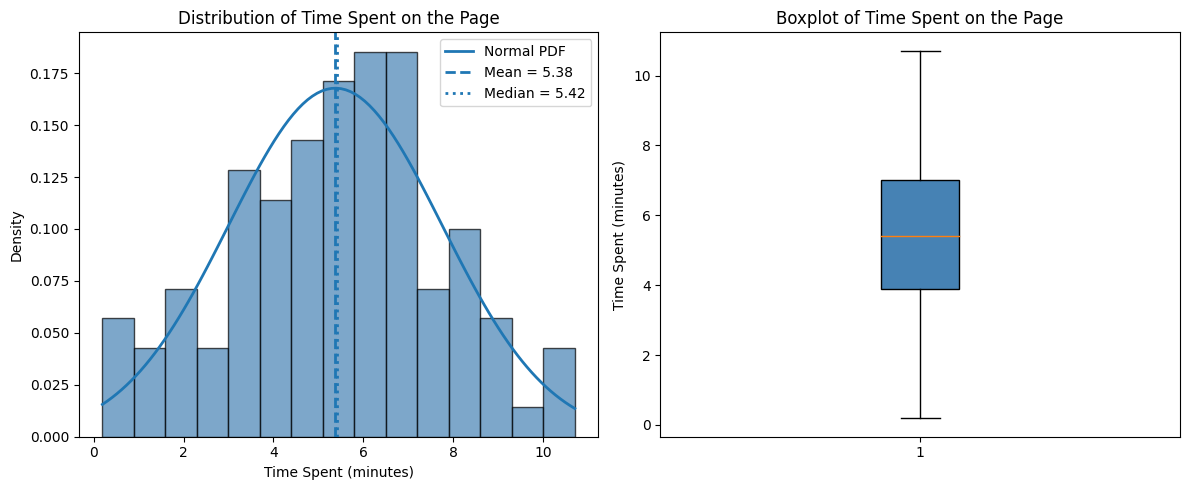

In [11]:
# Numerical Variable - time_spent_on_the_page

from scipy.stats import norm


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with PDF
data = ENews_df['time_spent_on_the_page']

# Histogram normalized to density
axes[0].hist(data, bins=15, density=True,
             color='steelblue', edgecolor='black', alpha=0.7)

# Calculate mean, median and standard deviation
mu = data.mean()
median = data.median()
sigma = data.std()

# Generate 100 evenly spaced x values between min and max for a smooth PDF curve
x = np.linspace(data.min(), data.max(), 100)

# Compute the probability density function (PDF) values using the normal distribution
pdf = norm.pdf(x, mu, sigma)

# Plot PDF
axes[0].plot(x, pdf, linewidth=2, label='Normal PDF')

axes[0].set_title('Distribution of Time Spent on the Page')
axes[0].set_xlabel('Time Spent (minutes)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Add Mean and Median Lines
axes[0].axvline(mu, linestyle='--', linewidth=2,
                label=f'Mean = {mu:.2f}')

axes[0].axvline(median, linestyle=':', linewidth=2,
                label=f'Median = {median:.2f}')

axes[0].set_title('Distribution of Time Spent on the Page')
axes[0].set_xlabel('Time Spent (minutes)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot Boxplot to visualize spread, median and potential outliers
axes[1].boxplot(data, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'))
axes[1].set_title('Boxplot of Time Spent on the Page')
axes[1].set_ylabel('Time Spent (minutes)')

plt.tight_layout() # Adjust layout to prevent overlapping 
plt.show()





#### Insights on time_spent_on_the_page

The histogram with the overlaid normal probability density function (PDF) suggests that the time spent on the page is approximately normally distributed. The distribution is centered around 5–6 minutes and displays a bell-shaped pattern, indicating that most users spend a moderate amount of time on the page, while relatively few users spend very short or very long durations.

The mean time spent on the page is 5.38 minutes and the median is 5.42 minutes. Since these values are very close, the distribution appears fairly symmetric with minimal skewness.

The interquartile range extends from approximately 3.88 minutes (Q1) to 7.02 minutes (Q3), indicating that 50% of users spend between these values. This reflects moderate variability in user engagement.

The boxplot does not show any significant outliers, suggesting that user engagement times are relatively consistent across the dataset.

Overall, user engagement time appears stable and well-behaved, making it suitable for further statistical comparison between groups.

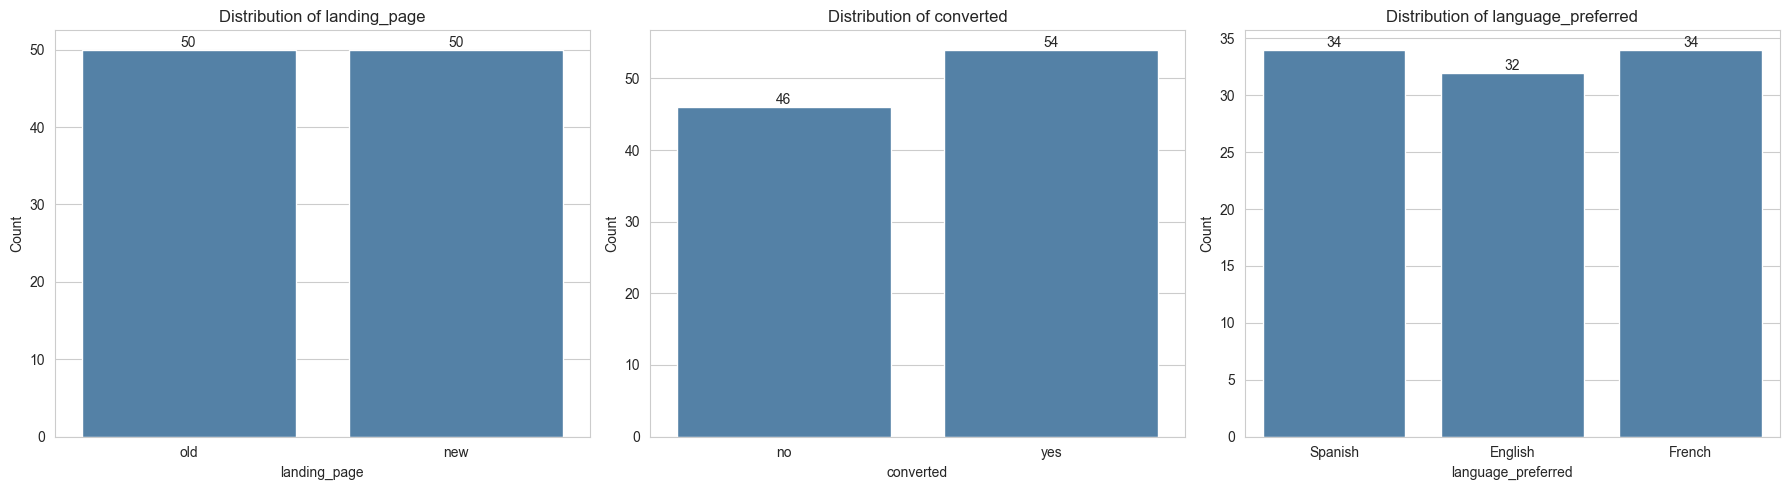

Frequency Table: landing_page
     Count  Percentage (%)
old     50            50.0
new     50            50.0


Frequency Table: converted
     Count  Percentage (%)
yes     54            54.0
no      46            46.0


Frequency Table: language_preferred
         Count  Percentage (%)
Spanish     34            34.0
French      34            34.0
English     32            32.0




In [12]:
# Categorical variables
categorical_cols = ['landing_page', 'converted', 'language_preferred']

# Set plot style
sns.set_style("whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Generate countplots
for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=ENews_df,
        x=col,
        ax=axes[i],
        color='steelblue'
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

    # Add count labels on bars
    for container in axes[i].containers:
        axes[i].bar_label(container)

plt.tight_layout()
plt.show()


# -----------------------------
# Frequency Tables
# -----------------------------

for col in categorical_cols:

    print("=" * 50)
    print(f"Frequency Table: {col}")
    print("=" * 50)

    # Counts
    count = ENews_df[col].value_counts()

    # Percentages
    percentage = (
        ENews_df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    # Combine into one table
    freq_table = pd.DataFrame({
        'Count': count,
        'Percentage (%)': percentage
    })

    print(freq_table)
    print("\n")

#### Insights from Categorical Variables

The users are evenly distributed between the old and new landing pages (50% each), indicating a balanced experimental design. This ensures a fair comparison between the two landing page versions without sampling bias.

A total of 54% of users subscribed to the e-newsletter, while 46% did not convert. This indicates a slightly higher overall conversion rate; however, further analysis is required to determine whether conversion is influenced by the landing page version.

Language preferences are nearly evenly distributed among Spanish (34%), French (34%), and English (32%) users. This balanced representation reduces the likelihood of language-related bias in subsequent analyses.

Overall, the dataset is well-balanced across key categorical variables, supporting reliable comparative and statistical analysis.

### Bivariate Analysis

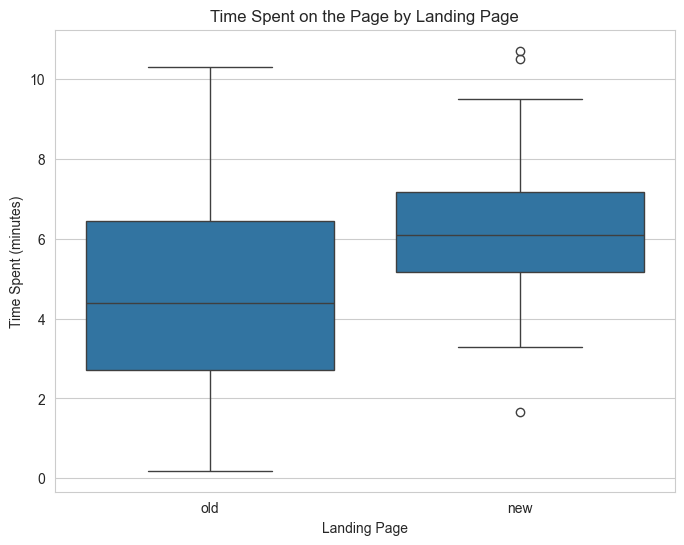

In [13]:
# Bivariate Analysis - Landing Page vs Time Spent on the Page
# Comparing user engagement (time spent) between the old and new landing pages

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=ENews_df,
    x='landing_page',
    y='time_spent_on_the_page'
)

plt.title('Time Spent on the Page by Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('Time Spent (minutes)')
plt.show()


#### Insights on Landing Page and Time Spent on the Page

Users on the new landing page show a higher median time spent (approximately 6.0 min) compared to the old landing page (approximately 4.5 min), suggesting higher engagement on the new design.

The new page also shows a slightly narrower IQR (approximately 5.4–7.0 min), indicating lower variability in the central 50% of user engagement times compared to the old page (approximately 2.8–6.4 min). This suggests a more consistent user experience among typical users.

Two outliers are present in the new page group (approximately 1.5 min and approximately 10.5 min), but they do not materially affect the overall distribution pattern.

Overall, the new landing page appears more effective at retaining user attention, but a formal statistical test would be required to determine whether the observed difference is statistically significant.

Converted unique values: ['no' 'yes']
Converted dtype: object


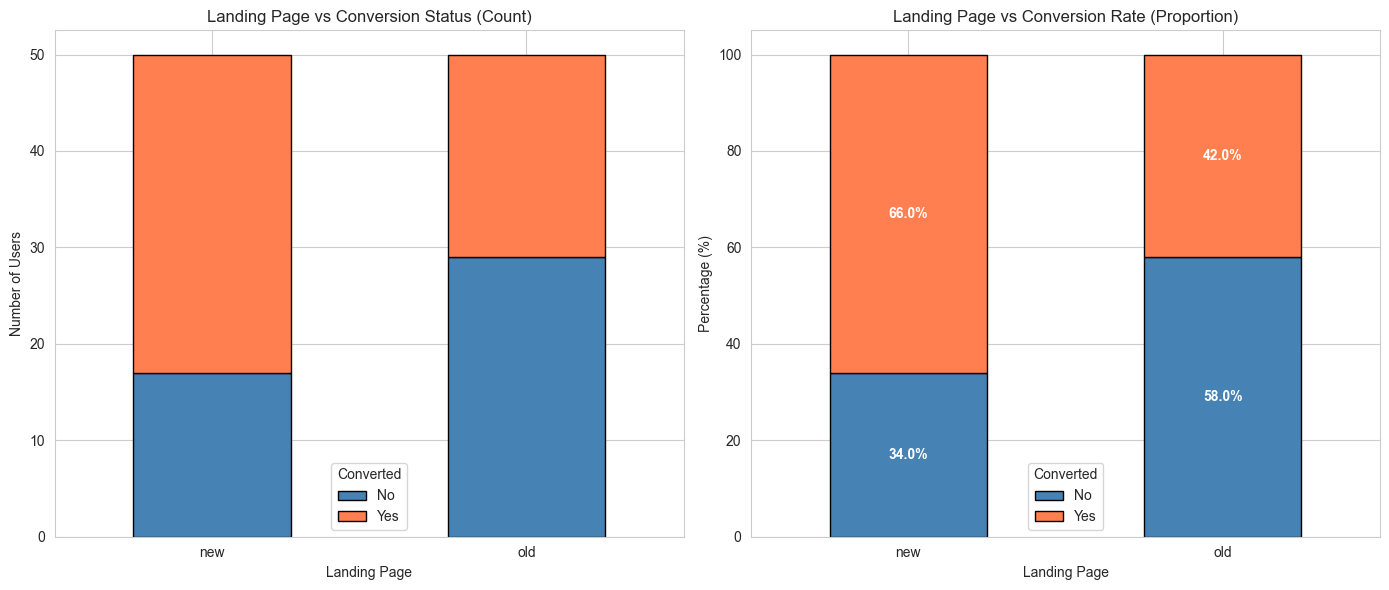

In [14]:
# Bivariate Analysis - Landing Page vs Conversion
# Comparing conversion rates between the old and new landing pages



# Check unique values in converted column
print("Converted unique values:", ENews_df['converted'].unique())
print("Converted dtype:", ENews_df['converted'].dtype)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# 1. Conversion Counts (Stacked Bar Chart)
# -------------------------------

# Create crosstab using actual column values (no reindex)
conversion_counts = pd.crosstab(
    ENews_df['landing_page'],
    ENews_df['converted']
)

# Plot stacked bar chart (counts)
conversion_counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['steelblue', 'coral'],
    edgecolor='black'
)

# Titles and labels
axes[0].set_title('Landing Page vs Conversion Status (Count)')
axes[0].set_xlabel('Landing Page')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Converted', labels=['No', 'Yes'])

# -------------------------------
# 2. Conversion Proportions (%)
# -------------------------------

# Create crosstab (row-wise percentages)
conversion_percent = pd.crosstab(
    ENews_df['landing_page'],
    ENews_df['converted'],
    normalize='index'
) * 100

# Plot stacked bar chart (percentages)
conversion_percent.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['steelblue', 'coral'],
    edgecolor='black'
)

# Add percentage labels on each bar segment
for bar in axes[1].patches:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_y() + height / 2
    # Only label meaningful segments
    if height > 3:
        axes[1].text(
            x, y,
            f'{height:.1f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )

# Titles and labels
axes[1].set_title('Landing Page vs Conversion Rate (Proportion)')
axes[1].set_xlabel('Landing Page')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Converted', labels=['No', 'Yes'])

# Layout adjustment
plt.tight_layout()
plt.show()



#### Insights on Landing Page and Conversion Rate

The new landing page shows a higher conversion rate of 66% compared to 42% for the old landing page. This suggests that the new page has higher conversion performance in converting users into newsletter subscribers.

More than half of users on the old landing page (58%) did not convert, indicating that the old page may be less effective at retaining user attention or encouraging subscription.

There is a 24 percentage point difference in conversion rates between the two pages. This provides strong preliminary evidence that the new landing page performs better, although a formal hypothesis test is required to confirm whether this difference is statistically significant.

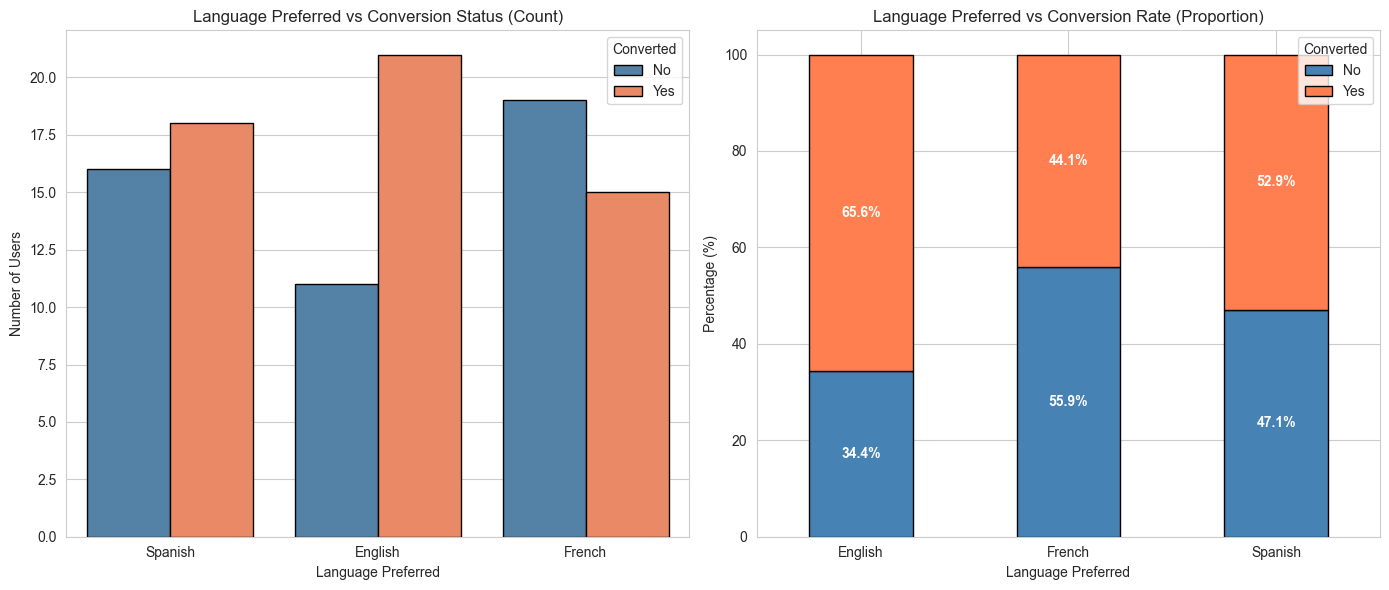

In [15]:
# Bivariate Analysis - Language Preferred vs Conversion Status
# Exploring the association between user language and conversion

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# 1. Countplot with Hue
# -------------------------------

# Plot count of conversions for each language group
sns.countplot(data=ENews_df, 
              x='language_preferred', 
              hue='converted',
              palette=['steelblue', 'coral'],
              edgecolor='black',
              ax=axes[0])

# Titles and labels
axes[0].set_title('Language Preferred vs Conversion Status (Count)')
axes[0].set_xlabel('Language Preferred')
axes[0].set_ylabel('Number of Users')
axes[0].legend(title='Converted', labels=['No', 'Yes'])

# -------------------------------
# 2. Proportion Plot
# -------------------------------

# Create crosstab (row-wise percentages)
lang_conversion = pd.crosstab(
    ENews_df['language_preferred'],
    ENews_df['converted'],
    normalize='index'
) * 100

# Plot stacked bar chart (proportions)
lang_conversion.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['steelblue', 'coral'],
    edgecolor='black'
)

# Add percentage labels on each bar segment
for bar in axes[1].patches:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_y() + height / 2
    if height > 3:
        axes[1].text(
            x, y,
            f'{height:.1f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )

# Titles and labels
axes[1].set_title('Language Preferred vs Conversion Rate (Proportion)')
axes[1].set_xlabel('Language Preferred')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Converted', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()



####  Insights on Language Preferred and Conversion Rate

English-speaking users had the highest conversion rate at 65.6%, meaning approximately two-thirds of English users subscribed to the e-newsletter. This is notably higher than both French and Spanish users.

French-speaking users had the lowest conversion rate at 44.1%, with the majority (55.9%) not converting. This indicates lower conversion performance compared to the other language groups.

Spanish-speaking users had a conversion rate of 52.9%, indicating a relatively balanced split between converted and not converted users.

There is a 21.5 percentage point difference between the highest (English: 65.6%) and lowest (French: 44.1%) conversion rates. This suggests that language preference may be associated with conversion rate differences; however, a formal statistical test is required to determine whether this difference is statistically significant.

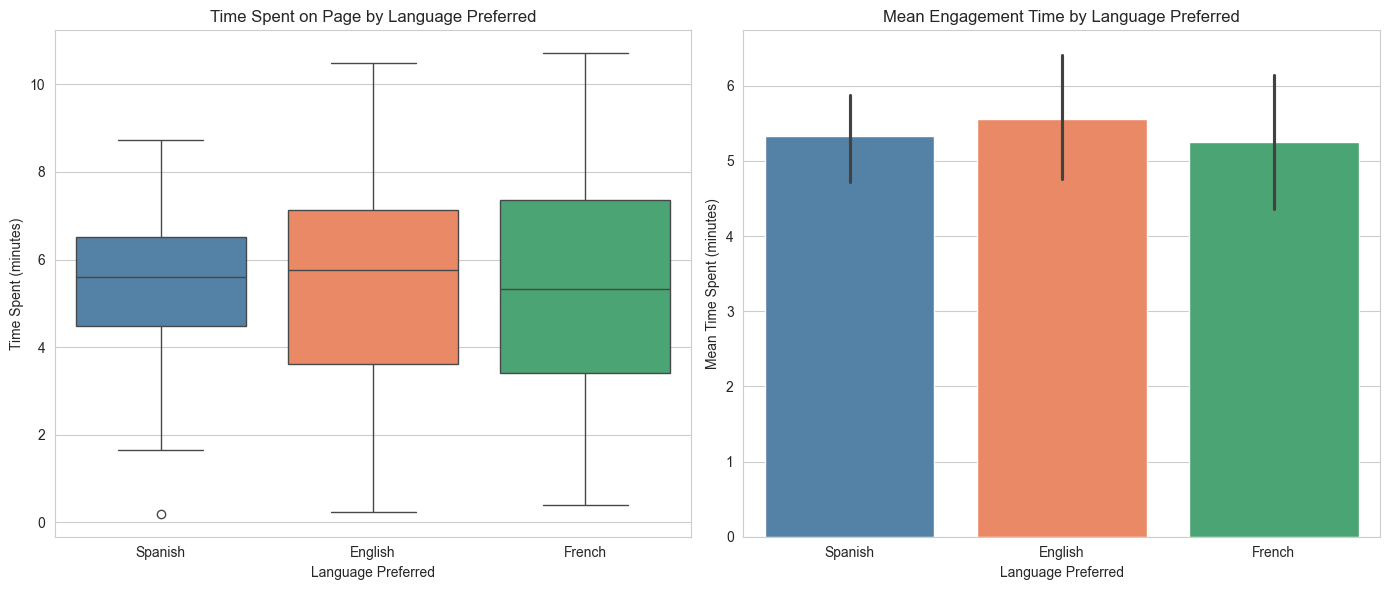

In [16]:
# Bivariate Analysis - Language Preferred vs Time Spent on Page
# Exploring engagement differences across language groups

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = ['English', 'French', 'Spanish']
palette = ['steelblue', 'coral', 'mediumseagreen']

# -------------------------------
# 1. Boxplot
# -------------------------------
sns.boxplot(
    data=ENews_df,
    x='language_preferred',
    y='time_spent_on_the_page',
    hue='language_preferred',
    palette=palette,
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Time Spent on Page by Language Preferred')
axes[0].set_xlabel('Language Preferred')
axes[0].set_ylabel('Time Spent (minutes)')

# -------------------------------
# 2. Barplot (Mean + CI)
# -------------------------------

sns.barplot(
    data=ENews_df,
    x='language_preferred',
    y='time_spent_on_the_page',
    hue='language_preferred',
    palette=palette,
    errorbar=('ci', 95),
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Mean Engagement Time by Language Preferred')
axes[1].set_xlabel('Language Preferred')
axes[1].set_ylabel('Mean Time Spent (minutes)')

plt.tight_layout()
plt.show()



#### Language Preferred vs Time Spent on Page - Insights

All three language groups show very similar mean engagement times, ranging from approximately 5.3 to 5.5 minutes. This suggests that language preference has minimal influence on the average time users spend on the page.

The Spanish group exhibits a relatively narrower IQR compared to the other groups, indicating lower variability in time spent. This suggests more consistent engagement among Spanish-speaking users.

Both English and French groups display wider IQRs, indicating greater variation in user engagement. Some users in these groups spent significantly less time, while others spent considerably longer on the page.

A single low outlier (close to approximately 0 minutes) is observed in the Spanish group, suggesting that one user exited the page almost immediately.

##### Overall Insight:

Since the mean engagement times are very similar across all three language groups, language preference does not appear to be a strong determinant of time spent on the page. However, a formal statistical test (e.g. ANOVA) would be required to determine whether any observed differences are statistically significant.

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

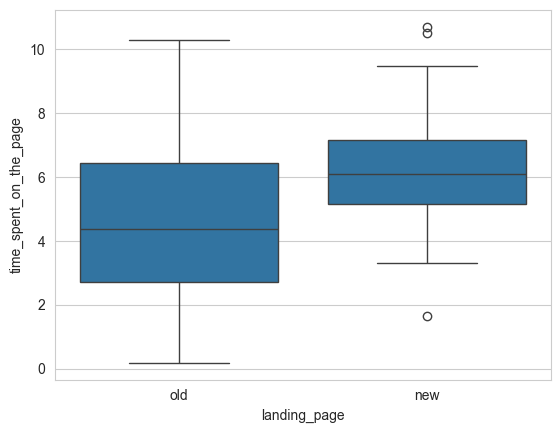

In [17]:
# Compare time spent distribution between old and new landing pages
sns.boxplot(data=ENews_df,
            x='landing_page',
            y='time_spent_on_the_page');

The boxplot indicates that the new landing page has a higher median time spent and a distribution shifted toward larger values compared to the old landing page. This provides preliminary evidence that users may spend more time on the new landing page, which can be verified through hypothesis testing.

### Step 1: Define the null and alternate hypotheses

##### Null and Alternative Hypotheses

$H_0: \mu_{new} \leq \mu_{old}$

$H_a: \mu_{new} > \mu_{old}$

### Step 2: Select Appropriate test

##### Test Selection 

Independent Two-sample test

Reasons:

1. The response variable (time_spent_on_the_page) is numerical and continuous
2. The population standard deviations are unknown, so a t-test is appropriate instead of a z-test.
3. We are comparing the mean time spent between two groups (old landing page vs. new landing page)
4. The two groups are independent, as each user is exposed to only one landing page.
5. The alternative hypothesis is $H_a: \mu_{new} > \mu_{old}$, requiring a right-tailed test

### Step 3: Decide the significance level



The significance level is set at 5% (alpha = 0.05), as specified in the Objective.

### Step 4: Collect and prepare data

In [18]:
# Group 1 - Time spent by users on the old landing page
old_page_time = ENews_df[ENews_df['landing_page'] == 'old']['time_spent_on_the_page']

# Group 2 - Time spent by users on the new landing page
new_page_time = ENews_df[ENews_df['landing_page'] == 'new']['time_spent_on_the_page']

# Quick summary of both groups
print("=" * 45)
print("  Old Landing Page - Time Spent Summary")
print("=" * 45)
print(f"  Sample Size : {len(old_page_time)}")
print(f"  Mean        : {old_page_time.mean():.2f} minutes")
print(f"  Std Dev     : {old_page_time.std():.2f} minutes")

print()

print("=" * 45)
print("  New Landing Page - Time Spent Summary")
print("=" * 45)
print(f"  Sample Size : {len(new_page_time)}")
print(f"  Mean        : {new_page_time.mean():.2f} minutes")
print(f"  Std Dev     : {new_page_time.std():.2f} minutes")


  Old Landing Page - Time Spent Summary
  Sample Size : 50
  Mean        : 4.53 minutes
  Std Dev     : 2.58 minutes

  New Landing Page - Time Spent Summary
  Sample Size : 50
  Mean        : 6.22 minutes
  Std Dev     : 1.82 minutes


The dataset contains time-spent information for **100 users**, evenly split between two independent groups:

- **Group 1 (Old Landing Page):** 50 users
- **Group 2 (New Landing Page):** 50 users

The variable of interest is **time_spent_on_the_page**, a continuous numerical variable measured in minutes.

Each user was exposed to only one version of the landing page, making the two groups independent. The dataset contains no missing values or duplicate observations. Therefore, the data are suitable for conducting an **independent two-sample t-test** to compare the mean time spent on the old and new landing pages.

### Step 5: Calculate the p-value

In [19]:
from scipy.stats import ttest_ind # Import independent samples t-test function from stats library

test_stat, p_value = ttest_ind(new_page_time,old_page_time, alternative='greater') # One-tailed t-test: tests if new page mean > old page mean
print(f"  Test Statistic     : {test_stat:.4f}")
print(f"  P-Value     : {p_value:.4f}") # Print p-value rounded to 4 decimal places


  Test Statistic     : 3.7868
  P-Value     : 0.0001


The independent two-sample t-test produced a test statistic of 3.7868 and a p-value of 0.0001.

### Step 6: Compare the p-value with $\alpha$

In [20]:
alpha = 0.05

print("=" * 45)
print("  Decision")
print("=" * 45)

if p_value < alpha:
    print(f"  P-value ({p_value:.4f}) < Alpha ({alpha})")
    print("  Reject the Null Hypothesis ✅")
else:
    print(f"  P-value ({p_value:.4f}) >= Alpha ({alpha})")
    print("  Fail to Reject the Null Hypothesis ❌")

  Decision
  P-value (0.0001) < Alpha (0.05)
  Reject the Null Hypothesis ✅


### Step 7:  Draw inference

The p-value (0.0001) is less than the significance level of 0.05. Therefore, we reject the null hypothesis.

At the 5% significance level, there is sufficient statistical evidence to conclude that users spend more time on the new landing page than on the old landing page.

This suggests that the new landing page is more effective at engaging users.

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

### Perform Visual Analysis

converted       no   yes
landing_page            
new           0.34  0.66
old           0.58  0.42


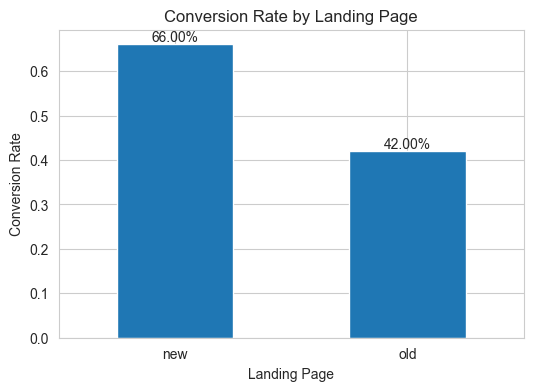

In [23]:
# Compute row-wise proportions: for each landing page, what fraction
# of visitors are in each 'converted' category ('yes' / 'no')
conversion_rate = pd.crosstab(
    ENews_df['landing_page'],   # rows: new_page / old_page
    ENews_df['converted'],      # columns: yes / no
    normalize='index'           # divide each row by its row total → proportions
)

# Preview the proportions table (2 rows × 2 columns)
print(conversion_rate)

# Plot only the 'yes' column (converted = yes) as a vertical bar chart
ax = conversion_rate['yes'].plot(
    kind='bar',
    figsize=(6, 4)        # width=6in, height=4in
)

# ── Chart labels & formatting ──────────────────────────────────────────────
plt.title('Conversion Rate by Landing Page')
plt.xlabel('Landing Page')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)    # keep x-axis labels horizontal (not angled)

# Annotate each bar with its exact percentage value
for p in ax.patches:                        # iterate over every bar rectangle
    ax.annotate(
        f'{p.get_height():.2%}',            # format proportion as "12.34%"
        (p.get_x() + p.get_width() / 2,    # x: horizontal center of the bar
         p.get_height()),                   # y: top edge of the bar
        ha='center',                        # center text horizontally
        va='bottom'                         # anchor text just above the bar top
    )

plt.show();

### Observations & Insights

1. The new landing page shows a higher conversion rate -The chart indicates that users who viewed the new landing page converted at a higher rate than those who viewed the old landing page. This suggests that the new page may be more effective at encouraging users to subscribe.

2. The difference in conversion rates is noticeable - The conversion rate for the new page exceeds that of the old page by approximately 24 percentage points (66% vs. 42%). This observed difference suggests a potentially meaningful improvement in user conversion.

3. A majority of users converted on the new page - Approximately two-thirds of users exposed to the new landing page converted, compared to less than half of users who viewed the old landing page. This provides preliminary evidence that the new page may perform better.

4. Statistical testing is required - While the visual analysis suggests that the new landing page has a higher conversion rate, a hypothesis test is needed to determine whether the observed difference is statistically significant and not due to random variation.

### Step 1: Define the null and alternate hypotheses

Let:

- $P_{new}$ = the population conversion rate for users who view the new landing page.
- $P_{old}$ = the population conversion rate for users who view the old landing page.

##### Null and Alternative Hypotheses

$H_0: P_{new} \leq P_{old}$

$H_a: P_{new} > P_{old}$

### Step 2: Select Appropriate test

#### Two-Proportion Z-Test

**Reasons:**

1. **The outcome variable is binary.**  
   The variable `converted` has two possible outcomes: **yes** or **no**. Therefore, we are comparing conversion rates (proportions) rather than averages (means). A t-test is not appropriate because it is used to compare means.

2. **The two groups are independent.**  
   Users were assigned to either the new landing page or the old landing page. Each user belongs to only one group, and the outcome of one user does not affect another user.

3. **The sample size is sufficiently large.**  
   Both groups contain enough observations to satisfy the success-failure condition (np ≥ 5 and n(1 − p) ≥ 5). This allows the sampling distribution of the difference in proportions to be approximated by a normal distribution.

4. **We are comparing two population proportions.**  
   The goal is to determine whether the conversion rate of the new landing page is higher than that of the old landing page. A two-proportion z-test is appropriate because it is specifically designed to compare two independent population proportions.

### Step 3: Decide the significance level


The significance level is set at 5% (alpha = 0.05), as specified in the Objective.

### Step 4: Collect and prepare data

In [24]:
# Number of conversions (successes) in each group
successes = ENews_df.groupby('landing_page')['converted'].apply(lambda x: (x == 'yes').sum())

# Total number of users in each group
sample_sizes = ENews_df.groupby('landing_page')['converted'].count()

print("Conversions:")
print(successes)

print("\nSample Sizes:")
print(sample_sizes)

Conversions:
landing_page
new    33
old    21
Name: converted, dtype: int64

Sample Sizes:
landing_page
new    50
old    50
Name: converted, dtype: int64


The data were divided into two independent groups based on the landing page viewed. The new landing page group consisted of 50 users, of whom 33 converted. The old landing page group also consisted of 50 users, of whom 21 converted. Therefore, the observed conversion rates were 66% for the new landing page and 42% for the old landing page. These sample sizes and conversion counts will be used to perform the two-proportion z-test.

### Step 5: Calculate the p-value

In [35]:
from statsmodels.stats.proportion import proportions_ztest # imports proportion ztest from stats.proportion library


# Success counts
conv_new = (ENews_df[ENews_df['landing_page'] == 'new']['converted'] == 'yes').sum()
conv_old = (ENews_df[ENews_df['landing_page'] == 'old']['converted'] == 'yes').sum()

# Sample sizes
n_new = (ENews_df['landing_page'] == 'new').sum()
n_old = (ENews_df['landing_page'] == 'old').sum()

# Data for z-test
converted = np.array([conv_new, conv_old])
sample_sizes = np.array([n_new, n_old])

# Two-proportion z-test
test_stat, p_value = proportions_ztest(converted, sample_sizes, alternative='larger')

print(f"  Test Statistic : {test_stat:.4f}")   
print(f"  P-Value        : {p_value:.4f}")

  Test Statistic : 2.4077
  P-Value        : 0.0080


The two proportional z- test produced a test statistic of 2.4077 and a p-value of 0.0080.

### Step 6: Compare the p-value with $\alpha$

In [36]:
alpha = 0.05

print("=" * 45)
print("  Decision")
print("=" * 45)

if p_value < alpha:
    print(f"  P-value ({p_value:.4f}) < Alpha ({alpha})")
    print("  Reject the Null Hypothesis ✅")
else:
    print(f"  P-value ({p_value:.4f}) >= Alpha ({alpha})")
    print("  Fail to Reject the Null Hypothesis ❌")

  Decision
  P-value (0.0080) < Alpha (0.05)
  Reject the Null Hypothesis ✅


### Step 7:  Draw inference


Since the p-value (0.0080) is less than the significance level of 0.05, we reject the null hypothesis.

There is sufficient evidence to conclude that the conversion rate for the new landing page is higher than the conversion rate for the old landing page. Therefore, the new landing page appears to be more effective at converting users.

## 3. Is the conversion and preferred language are independent or related?

## 4. Is the time spent on the new page same for the different language users?

## Conclusion and Business Recommendations

___